In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

from src.DataLoad_ResaleTransactions import load_transactions
from src.InterimAnalysis_ResaleTransactions import (market_snapshot,
                                                    yearly_summary,
                                                    monthly_summary,
                                                    town_summary,
                                                    flat_type_summary,
                                                    add_bands
                                                    )
from src.InterimPlot_ResaleTransactions import (output_path,
                                                _save,
                                                plot_yearly_volume_price,
                                                plot_monthly_volume_price,
                                                plot_town_ranking,
                                                plot_price_distribution,
                                                plot_band_vs_price
                                                )

sns.set_theme(style = 'whitegrid')
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
# load and add bands
df = load_transactions()
df = add_bands(df)
df.shape

(239265, 21)

In [3]:
df.tail()

,trx_date,trx_year,trx_month,lease_commence,flat_year,remaining_lease_month,flat_type,flat_model,town,street_name,...,storey_lower,storey_midpoint,storey_upper,price_per_sqm,floor_area_sqm,resale_price,area_band,storey_band,age_band,lease_band
239260,2026-05-01,2026,5,1988,38,729,EXECUTIVE,Apartment,YISHUN,YISHUN ST 81,...,7,8,9,7371.64,145.00,1068888.00,120+,07-09,30-39 yrs,60-69 yrs
239261,2026-07-01,2026,7,1987,39,726,EXECUTIVE,Maisonette,YISHUN,YISHUN ST 81,...,7,8,9,7000.00,145.00,1015000.00,120+,07-09,30-39 yrs,60-69 yrs
239262,2026-07-01,2026,7,1988,38,726,EXECUTIVE,Maisonette,YISHUN,YISHUN ST 81,...,4,5,6,6678.08,146.00,975000.00,120+,04-06,30-39 yrs,60-69 yrs
239263,2026-05-01,2026,5,1987,39,728,MULTI-GENERATION,Multi Generation,YISHUN,YISHUN AVE 4,...,4,5,6,6829.27,164.00,1120000.00,120+,04-06,30-39 yrs,60-69 yrs
239264,2026-07-01,2026,7,1988,38,727,MULTI-GENERATION,Multi Generation,YISHUN,YISHUN ST 61,...,7,8,9,7300.61,163.00,1190000.00,120+,07-09,30-39 yrs,60-69 yrs


In [5]:
# town summary
towns = town_summary(df, min_trx = 100)
towns.head(15)

,town,transactions,mean_price,median_price,mean_pps,median_pps,mean_area,median_area
6,BUKIT TIMAH,580,788434.85,784000.00,7108.72,6786.89,109.27,104.00
2,BISHAN,4162,718672.06,700000.00,6667.32,6422.12,107.41,105.00
18,QUEENSTOWN,6546,650610.06,675000.00,7749.70,7529.07,82.16,83.00
4,BUKIT MERAH,9111,646236.99,661888.00,7337.27,6982.76,87.05,90.00
16,PASIR RIS,6928,595548.64,580000.00,5030.15,4903.85,119.78,122.00
7,CENTRAL AREA,1856,701779.71,575000.00,8333.05,7699.10,81.70,82.00
14,KALLANG/WHAMPOA,7293,601610.02,574000.00,6855.58,6274.51,86.52,89.00
22,TAMPINES,16583,574047.08,550000.00,5597.34,5373.83,103.91,104.00
21,SERANGOON,4208,571735.17,535000.00,5662.70,5634.92,101.12,100.00
17,PUNGGOL,17306,551031.91,535000.00,5850.93,5736.84,95.21,93.00


In [6]:
# the most expensive and least expensive towns
towns = town_summary(df, min_trx = 100, by_col = 'mean_pps')
plot_town_ranking(towns, top_n = 10, by = True, by_col = 'mean_pps', name = 'town_most_expensive', path = None)
plot_town_ranking(towns, top_n = 10, by = False, by_col = 'mean_pps', name = 'town_least_expensive', path = None)

Saved: E:\AI study\HDB_resale_market_analysis\src\..\figures\town_most_expensive.png
Saved: E:\AI study\HDB_resale_market_analysis\src\..\figures\town_least_expensive.png


'E:\\AI study\\HDB_resale_market_analysis\\src\\..\\figures\\town_least_expensive.png'

In [7]:
# flat type summary
ft = flat_type_summary(df)
ft

,flat_type,transactions,mean_price,median_price,mean_pps,median_pps,mean_area,median_area
6,MULTI-GENERATION,88,869441.23,846500.00,5401.71,5180.85,161.35,164.00
5,EXECUTIVE,17007,743599.23,728000.00,5130.45,5028.38,144.85,146.00
4,5 ROOM,58517,635333.23,612000.00,5416.46,5190.08,117.72,117.00
3,4 ROOM,101649,539798.63,510000.00,5716.55,5380.95,95.02,93.00
2,3 ROOM,56897,378916.94,360000.00,5574.67,5315.07,68.13,67.00
1,2 ROOM,5020,307661.14,313000.00,6760.45,6808.51,45.70,47.00
0,1 ROOM,87,216068.18,215000.00,6969.94,6935.48,31.00,31.00


In [10]:
# flat type plot
fig, ax = plt.subplots(figsize = (9, 5))
sns.barplot(data = ft, x = 'flat_type', y = 'median_price', ax = ax, width = 0.6, color = 'purple')
for i in range(len(ft)):
    ax.text(x = ft['flat_type'][i], y = ft['median_price'][i] + 100, s = str(ft['median_price'][i]), fontsize = 10, ha = 'center', va = 'bottom')
ax.set_title('Median Resale Price by Flat Type')
ax.set_ylabel('Median Price (SGD)')
ax.tick_params(axis = 'x', rotation = 30)
fig.tight_layout()
_save(fig, name = 'medianprice_vs_flattype')

Saved: E:\AI study\HDB_resale_market_analysis\src\..\figures\medianprice_vs_flattype.png


'E:\\AI study\\HDB_resale_market_analysis\\src\\..\\figures\\medianprice_vs_flattype.png'

In [12]:
# other characteristics
plot_band_vs_price(df, 'area_band', 'price_per_sqm')
plot_band_vs_price(df, 'storey_band', 'price_per_sqm')
plot_band_vs_price(df, 'age_band', 'price_per_sqm')
plot_band_vs_price(df, 'lease_band', 'price_per_sqm')

Saved: E:\AI study\HDB_resale_market_analysis\src\..\figures\area_band_vs_price_per_sqm.png
Saved: E:\AI study\HDB_resale_market_analysis\src\..\figures\storey_band_vs_price_per_sqm.png
Saved: E:\AI study\HDB_resale_market_analysis\src\..\figures\age_band_vs_price_per_sqm.png
Saved: E:\AI study\HDB_resale_market_analysis\src\..\figures\lease_band_vs_price_per_sqm.png


'E:\\AI study\\HDB_resale_market_analysis\\src\\..\\figures\\lease_band_vs_price_per_sqm.png'

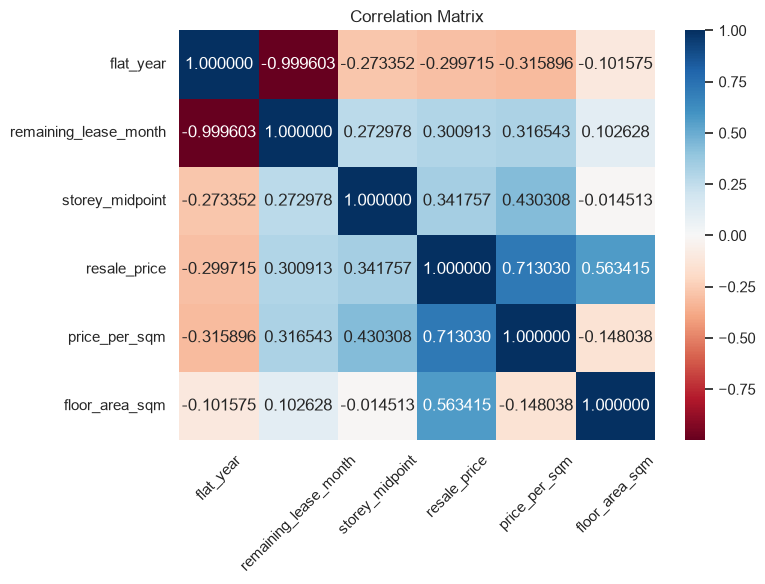

Saved: E:\AI study\HDB_resale_market_analysis\src\..\figures\correlation_heatmap.png


'E:\\AI study\\HDB_resale_market_analysis\\src\\..\\figures\\correlation_heatmap.png'

In [15]:
# correalation
cols = ['flat_year', 'remaining_lease_month', 'storey_midpoint',
        'resale_price', 'price_per_sqm', 'floor_area_sqm']
corr = df[cols].corr()
fig, ax = plt.subplots(figsize = (8, 6))
sns.heatmap(corr, annot = True, fmt = '2f', cmap = 'RdBu', center = 0, ax = ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation = 45)
ax.set_yticklabels(ax.get_yticklabels(), rotation = 0)
ax.set_title("Correlation Matrix")
fig.tight_layout()
plt.show()
_save(fig, 'correlation_heatmap')